# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [7]:
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
student_data

,Age,Tardies
0,17,10
1,51,1
2,27,5
3,21,9
4,36,4
5,48,2
6,19,9
7,26,6
8,54,0
9,30,3


Draw a dispersion diagram (scatter plot) for the data.

<Axes: xlabel='Age', ylabel='Tardies'>

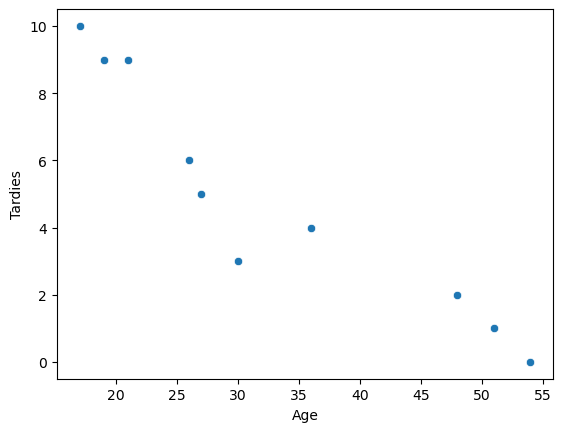

In [6]:
sns.scatterplot(data=student_data, x="Age", y="Tardies")

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

From the scatterplot we can see that there is a relation between "Tardies" and "Age", the yourger students have a high number of "tardies" and the older studentshave a low number of "tardies", We can say that the number of tardies decreases when the age of the students increases. 

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [8]:
# Covarianza
cov = student_data.cov()

# Correlación (coeficiente de Pearson)
corr = student_data.corr()

print("Covarianza:\n", cov)
print("\nCorrelación:\n", corr)
# The covariance and the correlations show us that the "age" and "Tardies" have a negative relation, and the correlation 1.0 and -0.9 is very high so its shows a strong relations.

Covarianza:
                 Age    Tardies
Age      187.655556 -45.566667
Tardies  -45.566667  12.544444

Correlación:
               Age   Tardies
Age      1.000000 -0.939163
Tardies -0.939163  1.000000


Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [12]:
seed = 1

X = student_data[['Age']] 
y = student_data['Tardies']               


model = LinearRegression()
model.fit(X, y)

w0 = model.intercept_
w1 = model.coef_[0]

print("w1:", w1)
print("w0:", w0)
print("Prediction for Age=30:", model.predict([[30]])[0])

# For this date I built a Simple Linear Regression model, the outcome will be the number of Tardies acording to the Age of the students. 

w1: -0.2428207709159809
w0: 12.888803363135771
Prediction for Age=30: 5.604180235656345


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Plot your regression model on your scatter plot.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


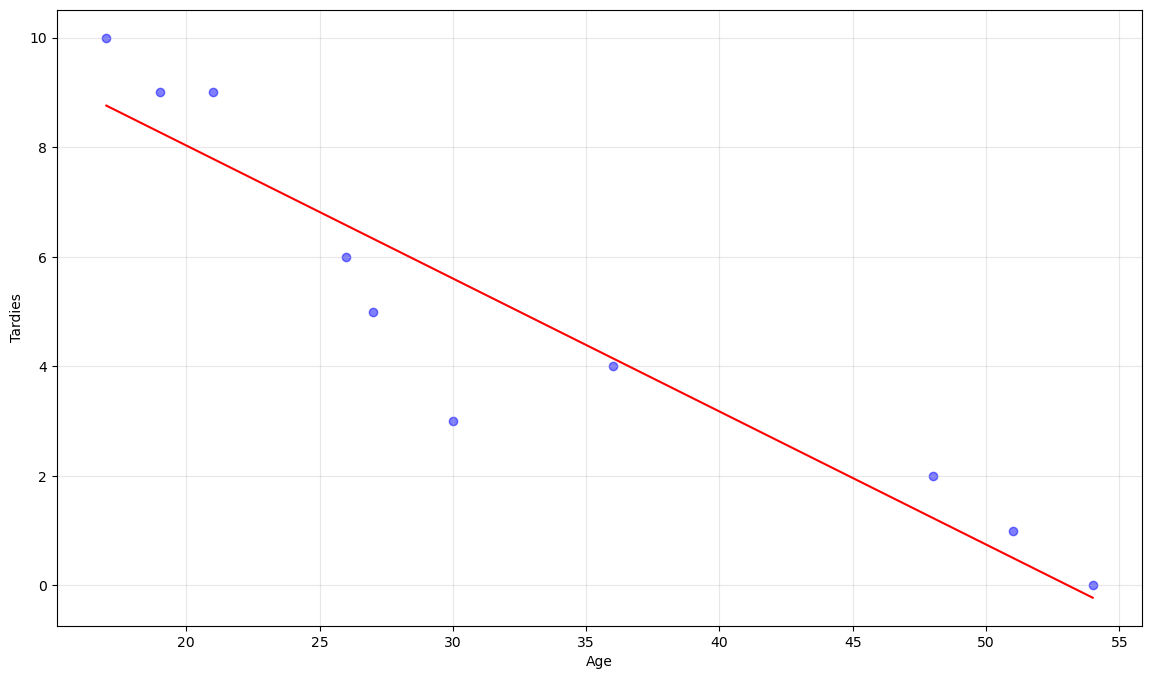

In [17]:

plt.figure(figsize=(14, 8))

plt.scatter(X, y, alpha=0.5, color='blue')

# Línea de regresión
X_linea = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
hw_linea = model.predict(X_linea)
plt.plot(X_linea, hw_linea, color='red')

plt.xlabel('Age')
plt.ylabel('Tardies', rotation=90)
plt.grid(True, alpha=0.3)
plt.show()


Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

This model shows that in fact there is a negative relation between "Age" of the students and number of "Tardies". 

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [19]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("vehicles.csv")
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [28]:

variables = [
    'Year',
    'Cylinders',
    'Fuel Barrels/Year',
    'Combined MPG',
    'Fuel Cost/Year',
    'CO2 Emission Grams/Mile'
]

# Subconjunto solo con las columnas necesarias
vehicles_sub = vehicles[variables]

# Calcular correlaciones respecto al outcome
correlations = vehicles_sub.corr()['CO2 Emission Grams/Mile'].sort_values(ascending=False)
print(correlations)

#The "Fuel Barrels/Year" has the strongest relation and shows the most important informations and "Year" the weakest information. 

CO2 Emission Grams/Mile    1.000000
Fuel Barrels/Year          0.986189
Fuel Cost/Year             0.930865
Cylinders                  0.752393
Year                      -0.222300
Combined MPG              -0.926229
Name: CO2 Emission Grams/Mile, dtype: float64


Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [30]:
X = vehicles_sub.drop("CO2 Emission Grams/Mile", axis=1)
y = vehicles_sub["CO2 Emission Grams/Mile"]

model_v = LinearRegression()
model_v.fit(X, y)

wo = model_v.intercept_

# Get the feature names from X
variables = X.columns.tolist()


# Create a DataFrame that shows each variable with its coefficient
# Note: using model_v instead of model
coef_df = pd.DataFrame({
    'Variable': variables,
    'Coefficient': model_v.coef_  # This will work if variables and coefficients have the same length
})

print(coef_df)

#Foe this data I'm buildong a Multiple Linear Regression model.

            Variable  Coefficient
0               Year    -0.320617
1          Cylinders     1.878800
2  Fuel Barrels/Year    19.052925
3       Combined MPG    -3.040399
4     Fuel Cost/Year     0.032309


Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [35]:
party = pd.DataFrame({"X": [1, 3, 4, 6, 8, 9, 11, 14], "y": [1, 2, 4, 4, 5, 7, 8, 13]})

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

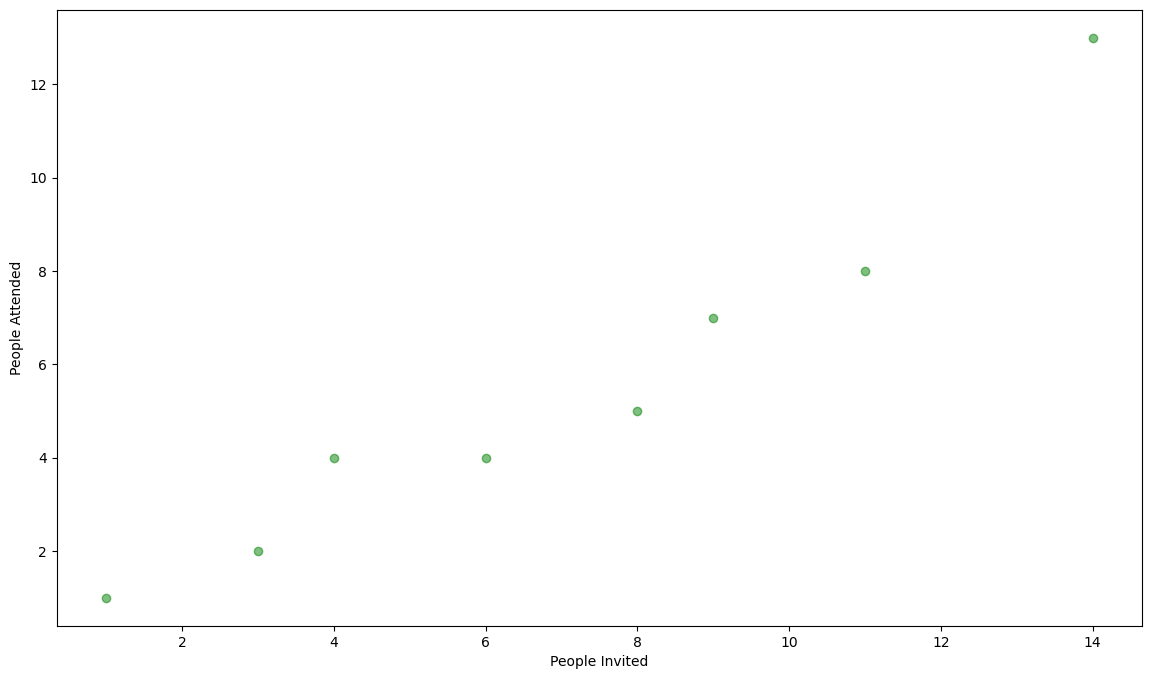

In [43]:
plt.figure(figsize=(14, 8))
plt.scatter(party.X,  party.y,  alpha=0.5, color='green')
plt.xlabel("People Invited")
plt.ylabel("People Attended")
plt.show()

X = party.X.values.reshape(-1, 1)
y = party.y

model_p = LinearRegression()
model_p.fit(X, y)

wo = model_p.intercept_
w1 = model_p.coef_[0]



What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

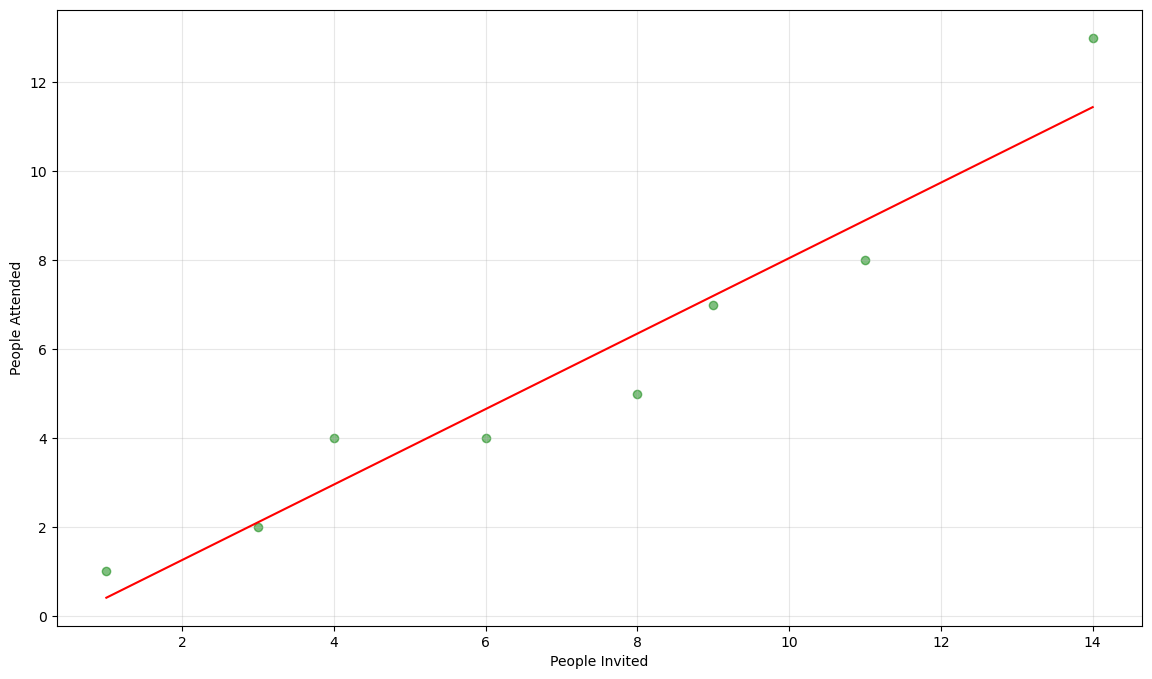

In [44]:
plt.figure(figsize=(14, 8))
plt.scatter(party.X,  party.y,  alpha=0.5, color='green')

# Línea de regresión
X_linea = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
hw_linea = model_p.predict(X_linea)
plt.plot(X_linea, hw_linea, color='red')

plt.xlabel("People Invited")
plt.ylabel("People Attended")
plt.grid(True, alpha=0.3)
plt.show()


There is a positive relation between the amount of people invited and the amount of people that attended to the parties. 

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

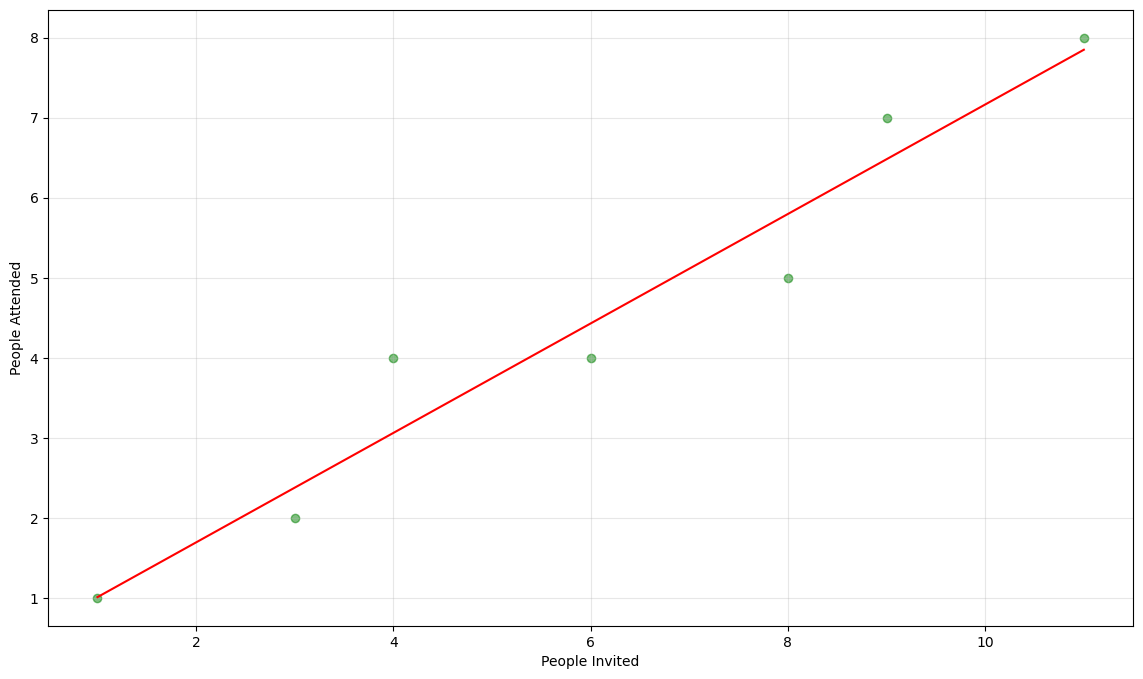

In [49]:

party_clean = pd.DataFrame({"X": [1, 3, 4, 6, 8, 9, 11], "y": [1, 2, 4, 4, 5, 7, 8]})
X_clean = party_clean.X.values.reshape(-1, 1)
y_clean = party_clean.y

# Nuevo modelo
model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)

w0 = model_clean.intercept_
w1 = model_clean.coef_[0]


plt.figure(figsize=(14, 8))
plt.scatter(party_clean.X,  party_clean.y,  alpha=0.5, color='green')

# Línea de regresión
X_linea = np.linspace(X_clean.min(), X_clean.max(), 100).reshape(-1, 1)
hw_linea = model_clean.predict(X_linea)
plt.plot(X_linea, hw_linea, color='red')

plt.xlabel("People Invited")
plt.ylabel("People Attended")
plt.grid(True, alpha=0.3)
plt.show()

#We delete the last point of the fdatframe that can be consider as an outlier. 

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

The model became more accurate.